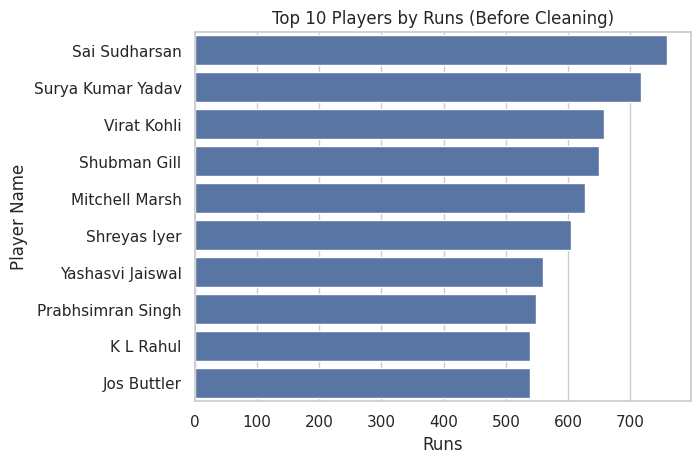

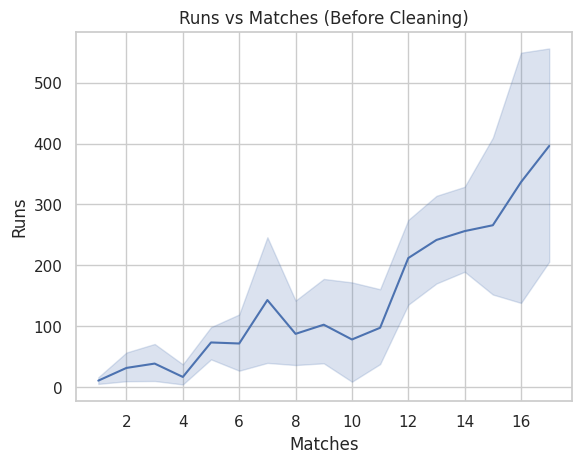

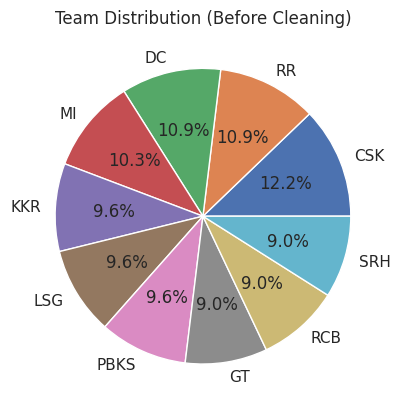

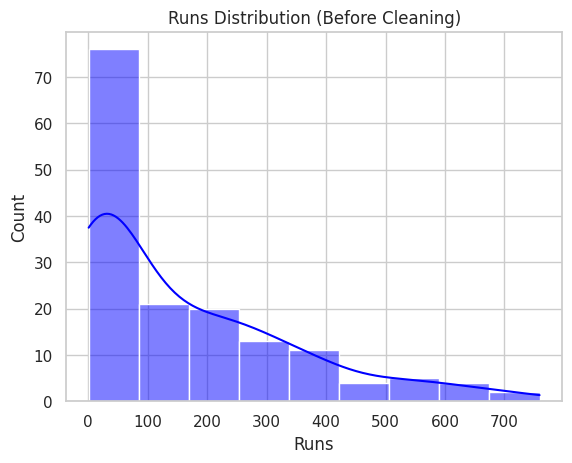

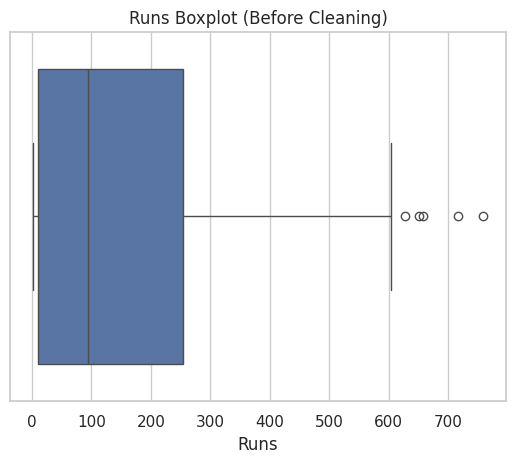


After Cleaning:
         Player Name Team  Runs  Matches  Inn  No   HS    AVG   BF      SR  \
0      Sai Sudharsan   GT   759       15   15   1  108  54.21  486  156.17   
1  Surya Kumar Yadav   MI   717       16   16   5   73  65.18  427  167.91   
2        Virat Kohli  RCB   657       15   15   3   73  54.75  454  144.71   
3       Shubman Gill   GT   650       15   15   2   93  50.00  417  155.87   
4     Mitchell Marsh  LSG   627       13   13   0  117  48.23  383  163.70   

   100s  50s  4s  6s  
0     1    6  88  21  
1     0    5  69  38  
2     0    8  66  19  
3     0    6  62  24  
4     1    6  56  37  


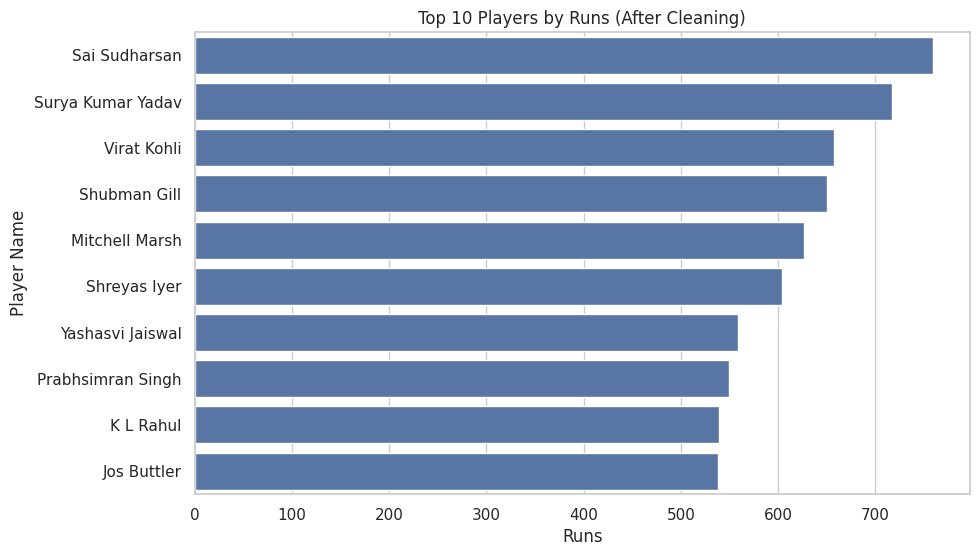

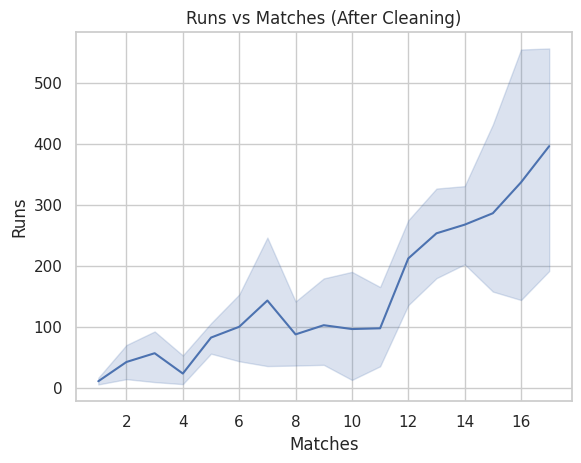

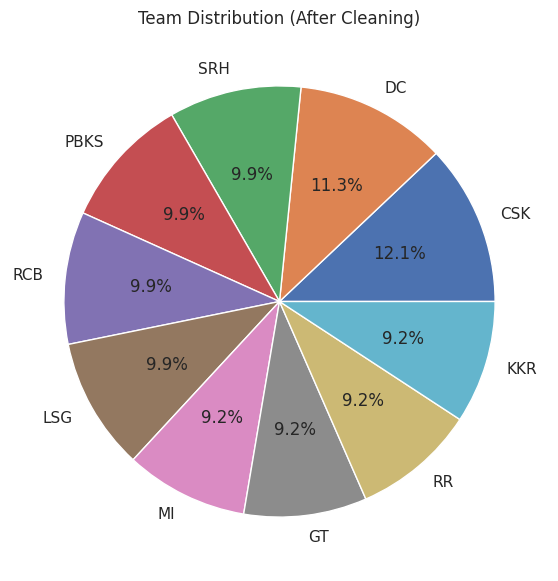

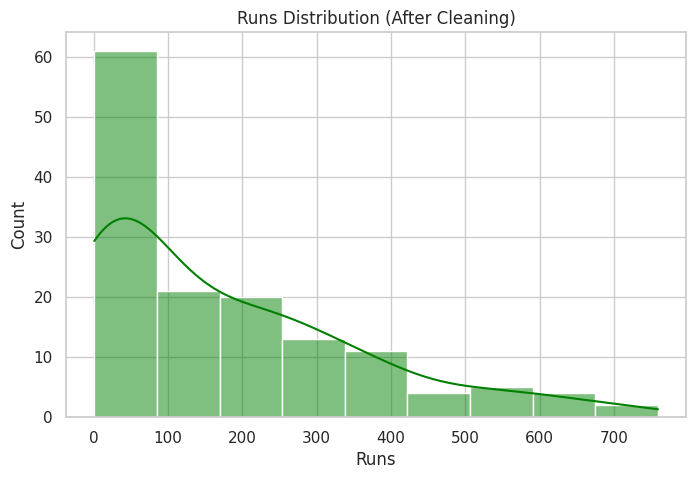

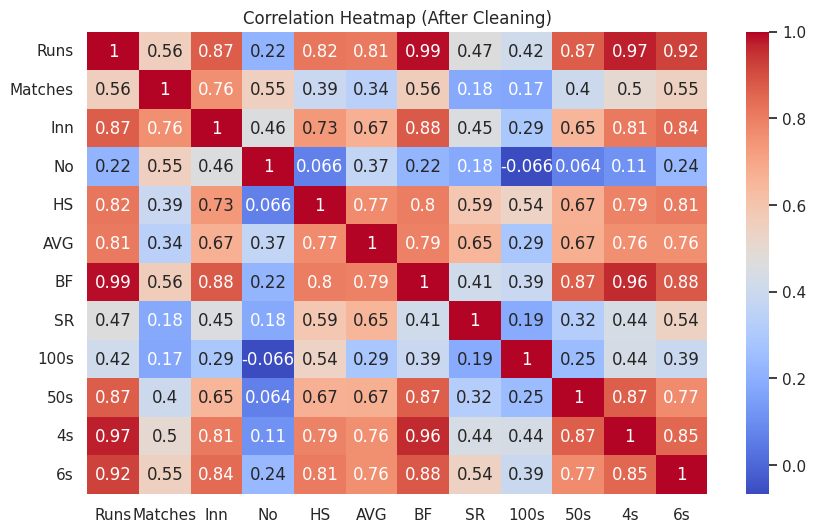

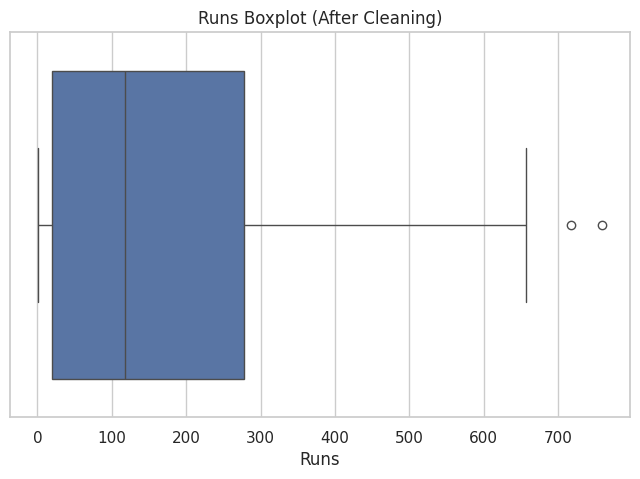

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv("/content/IPL2025Batters.csv")


df.head()

# -----------------------------
# 2. BEFORE CLEANING VISUALS
# -----------------------------

# BAR GRAPH - Top 10 Runs

sns.barplot(x='Runs', y='Player Name', data=top10)
plt.title("Top 10 Players by Runs (Before Cleaning)")
plt.show()

# LINE CHART - Runs vs Matches

sns.lineplot(x='Matches', y='Runs', data=df)
plt.title("Runs vs Matches (Before Cleaning)")
plt.show()

# PIE CHART - Team distribution

plt.pie(team_counts, labels=team_counts.index, autopct='%1.1f%%')
plt.title("Team Distribution (Before Cleaning)")
plt.show()

# HISTOGRAM - Runs

sns.histplot(df['Runs'], kde=True, color='blue')
plt.title("Runs Distribution (Before Cleaning)")
plt.show()


# BOXPLOT - Runs

sns.boxplot(x=df['Runs'])
plt.title("Runs Boxplot (Before Cleaning)")
plt.show()


# -----------------------------
# 3. DATA CLEANING
# -----------------------------

# Clean HS column
df['HS'] = df['HS'].astype(str).str.replace('*', '', regex=False)
df['HS'] = pd.to_numeric(df['HS'], errors='coerce')

# Convert numeric columns
cols = ['Runs','Matches','Inn','AVG','BF','SR','100s','50s','4s','6s']
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

# Drop missing values & duplicates
df = df.dropna()
df = df.drop_duplicates()

print("\nAfter Cleaning:")
print(df.head())


# -----------------------------
# 4. AFTER CLEANING VISUALS
# -----------------------------

# BAR GRAPH
top10_clean = df.sort_values(by='Runs', ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x='Runs', y='Player Name', data=top10_clean)
plt.title("Top 10 Players by Runs (After Cleaning)")
plt.show()

# LINE CHART

sns.lineplot(x='Matches', y='Runs', data=df)
plt.title("Runs vs Matches (After Cleaning)")
plt.show()

# PIE CHART
team_counts_clean = df['Team'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(team_counts_clean, labels=team_counts_clean.index, autopct='%1.1f%%')
plt.title("Team Distribution (After Cleaning)")
plt.show()

# HISTOGRAM
plt.figure(figsize=(8,5))
sns.histplot(df['Runs'], kde=True, color='green')
plt.title("Runs Distribution (After Cleaning)")
plt.show()

# HEATMAP - Correlation
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (After Cleaning)")
plt.show()

# BOXPLOT
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Runs'])
plt.title("Runs Boxplot (After Cleaning)")
plt.show()